Cluster analysis - participants are categorized into groups based on marketing segmentation method:

- Geographic (not utilized since our research scope is limited to Australia)

- Demographic - Age, Gender, Education, Income

- Behavrioral - Frequency of social media usage, social importance, number of social influencers followed

- Psychological - Stay up-to-date, Openness of experience, Conscientiousness

In [4]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv('Social Influencer Dataset.csv',header=1)

In [6]:
df.head()

,RQ1,RQ2,RQ3,RQ4,RQ5,RQ6,RQ7,RQ8,RQ9,RQ10,...,RQ52,RQ53,RQ54,RQ55,RQ56,RQ57,RQ58,RQ59,RQ60,RQ61
0,5.0,"Yes, I follow a lot (more than 25)",2,5,1,2,1,5.0,2,1.0,...,18-24,Male,High school graduate,Yes,Unemployed looking for work,"Less than $10,000",4.6,2.50,3.50,4.00
1,2.0,"Yes, I follow a few (less than 5)",4,4,4,4,3,4.0,4,5.0,...,18-24,Male,Bachelor's degree,Yes,Other,"Less than $10,000",4.6,4.25,3.75,4.00
2,4.0,"Yes, I follow a lot (more than 25)",3,3,3,3,3,3.0,4,1.0,...,24-34,Male,Bachelor's degree,Yes,Employed full time,"$10,000 - $29,999",3.6,3.50,3.25,3.75
3,4.0,"Yes, I follow a lot (more than 25)",3,2,2,4,2,2.0,3,3.0,...,18-24,Male,Bachelor's degree,Yes,Other,"Less than $10,000",4.2,3.50,4.00,3.50
4,4.0,"Yes, I follow a lot (more than 25)",3,4,2,3,2,4.0,3,1.0,...,18-24,Female,Associate's degree or Diploma,Yes,Employed part time,"Less than $10,000",2.4,2.75,3.00,1.00


Preprocessing of Demo data

In [8]:
df_cluster=pd.DataFrame()

In [25]:
df_cluster['Demo_Gender'] = df['RQ53']
df_cluster['Demo_Education'] = df['RQ54']
df_cluster['Demo_Income'] = df['RQ57']

df_cluster.head()

,Demo_Age,Demo_Education,Demo_Income,Demo_Gender
0,18-24,High school graduate,"Less than $10,000",Male
1,18-24,Bachelor's degree,"Less than $10,000",Male
2,24-34,Bachelor's degree,"$10,000 - $29,999",Male
3,18-24,Bachelor's degree,"Less than $10,000",Male
4,18-24,Associate's degree or Diploma,"Less than $10,000",Female


In [26]:
print(df_cluster['Demo_Education'].value_counts())
print(df_cluster['Demo_Gender'].value_counts())
print(df_cluster['Demo_Income'].value_counts())



Demo_Education
Bachelor's degree                49
High school graduate             29
Master's degree                  12
Associate's degree or Diploma     8
Professional degree               2
Name: count, dtype: int64
Demo_Gender
Female    58
Male      41
Name: count, dtype: int64
Demo_Income
Less than $10,000      46
$10,000 - $29,999      20
$50,000 - $79,999      12
$30,000 - $49,999      10
$100,000 - $149,999     4
$80,000 - $99,999       3
More than $150,000      2
Name: count, dtype: int64


Split point development:

Education: 0 = Below Bachelors, 1 = Bachelors and above

Gender: 0 = Female, 1 = Male

Income: 0 = Lower than $10,000, 1 = above $10,000

In [29]:
df_cluster['Demo_Education']=df_cluster['Demo_Education'].replace(
    {
        "High school graduate":0,
        "Associate's degree or Diploma":0,
        "Professional degree":0,
        "Bachelor's degree":1,
        "Master's degree":1
    }
)

df_cluster['Demo_Gender'] = df_cluster['Demo_Gender'].replace({
    'Female': 0,
    'Male': 1
})

df_cluster['Demo_Income'] = df_cluster['Demo_Income'].replace({
    'Less than $10,000': 0,
    '$10,000 - $29,999': 1,
    '$30,000 - $49,999': 1,
    '$50,000 - $79,999': 1,
    '$80,000 - $99,999': 1,
    '$100,000 - $149,999': 1,
    'More than $150,000': 1,
})

C:\Users\lilai\AppData\Local\Temp\ipykernel_3632\759114607.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cluster['Demo_Education']=df_cluster['Demo_Education'].replace(
C:\Users\lilai\AppData\Local\Temp\ipykernel_3632\759114607.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cluster['Demo_Gender'] = df_cluster['Demo_Gender'].replace({
C:\Users\lilai\AppData\Local\Temp\ipykernel_3632\759114607.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain th

Preprocessing of behavioral data

In [71]:
df_cluster['Social_importance'] = df['RQ1']
df_cluster['Influence_follow'] = df['RQ2']
df_cluster['Frequency_1'] = df['RQ4']
df_cluster['Frequency_2'] = df['RQ5']
df_cluster['Frequency_3'] = df['RQ6']
df_cluster['Frequency_4'] = df['RQ7']

print(df_cluster['Influence_follow'].value_counts())


Influence_follow
Yes, I follow a lot (more than 25)     35
Yes, I follow a many (between 5-24)    34
Yes, I follow a few (less than 5)      22
No                                      5
Name: count, dtype: int64


Reverse coding for Frequency_4

In [88]:

df_cluster['Frequency_4'] = df_cluster['Frequency_4'].replace({
    1:5,
    2:4,
    3:3,
    4:2,
    5:1
})

In [72]:
print('the splitting point for influencer followed is: follows more than 25 = 1, follows less than 25 = 0')

df_cluster['Influence_follow'] = df_cluster['Influence_follow'].replace(
    {
        'Yes, I follow a lot (more than 25)':1,
        'Yes, I follow a many (between 5-24)':0,
        'Yes, I follow a few (less than 5)':0,
        'No':0
    }
)

the splitting point for influencer followed is: follows more than 25 = 1, follows less than 25 = 0


C:\Users\lilai\AppData\Local\Temp\ipykernel_3632\2216077276.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cluster['Influence_follow'] = df_cluster['Influence_follow'].replace(


In [73]:
df_cluster.dtypes

Demo_Education           Int64
Demo_Income              Int64
Demo_Gender              Int64
Social_importance_1      Int64
Social_importance_2      Int64
Influence_follow         int64
Frequency_1              int64
Frequency_2              int64
Frequency_3              int64
Frequency_4              int64
Social_importance      float64
dtype: object

In [74]:
df_cluster.isnull().sum()
df_cluster.dropna(inplace=True)
df_cluster['Demo_Education'] = df_cluster['Demo_Education'].astype('Int64')
df_cluster['Demo_Income'] = df_cluster['Demo_Income'].astype('Int64')
df_cluster['Demo_Gender'] = df_cluster['Demo_Gender'].astype('Int64')
df_cluster['Social_importance'] = df_cluster['Social_importance'].astype('Int64')
df_cluster['Frequency_1'] = df_cluster['Frequency_1'].astype('Int64')
df_cluster['Frequency_2'] = df_cluster['Frequency_2'].astype('Int64')
df_cluster['Frequency_3'] = df_cluster['Frequency_3'].astype('Int64')
df_cluster['Frequency_4'] = df_cluster['Frequency_4'].astype('Int64')

Reliability check for compound traits: Frequency

In [89]:
import pingouin as pg

Frequency = df_cluster[['Frequency_1','Frequency_2','Frequency_3','Frequency_4']]

alpha_frequency = pg.cronbach_alpha(Frequency)

print(alpha_frequency)


(np.float64(0.6264970059880239), array([0.488, 0.735]))


In [115]:
df_cluster['Frequency'] = df_cluster[['Frequency_1','Frequency_2','Frequency_3','Frequency_4']].mean(axis=1).astype(int)

In [116]:
df_cluster.head()

,Demo_Education,Demo_Income,Demo_Gender,Influence_follow,Frequency_1,Frequency_2,Frequency_3,Frequency_4,Social_importance,Frequency
0,0,0,1,1,5,1,2,5,5,3
1,1,0,1,0,4,4,4,3,2,3
2,1,1,1,1,3,3,3,3,4,3
3,1,0,1,1,2,2,4,4,4,3
4,0,0,0,1,4,2,3,4,4,3


以下是聚类分析

In [ ]:
df_cluster.columns

Index(['Demo_Education', 'Demo_Income', 'Demo_Gender', 'Influence_follow',
       'Frequency_1', 'Frequency_2', 'Frequency_3', 'Frequency_4',
       'Social_importance', 'Frequency'],
      dtype='object')

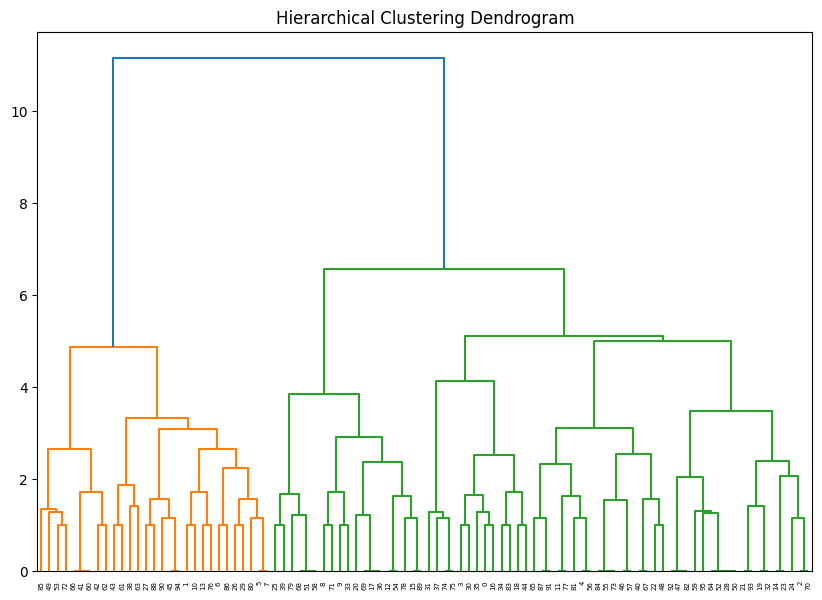

In [121]:
from scipy.cluster.hierarchy import linkage, dendrogram
from matplotlib import pyplot as plt

cluster_variables = pd.DataFrame()

cluster_variables = df_cluster.iloc[:, [0,1,2,3,8,9]]

links = linkage(cluster_variables, 'ward')

plt.figure(figsize=(10,7))
dendrogram(links)
plt.title('Hierarchical Clustering Dendrogram')
plt.show()

通过 dendrogram，确定 n_clusters = 5. 

In [125]:
from scipy.cluster.hierarchy import fcluster

cluster_label = fcluster(links, 5, criterion='maxclust')

df_cluster['Cluster_Labels'] = cluster_label
df_cluster.head()

,Demo_Education,Demo_Income,Demo_Gender,Influence_follow,Frequency_1,Frequency_2,Frequency_3,Frequency_4,Social_importance,Frequency,Cluster_Labels
0,0,0,1,1,5,1,2,5,5,3,3
1,1,0,1,0,4,4,4,3,2,3,1
2,1,1,1,1,3,3,3,3,4,3,5
3,1,0,1,1,2,2,4,4,4,3,3
4,0,0,0,1,4,2,3,4,4,3,4


至此，通过将参与者分为5个簇的聚类分析已经完成。接下来对各个簇进行解读。

解读分为以下几个步骤：

1.统计每个簇的人数
2.统计每个簇的属性值（连续变量：均值；分类变量：众数）
3.将属性值进行排序
4.将属性值进行可视化

In [126]:
df_cluster['Cluster_Labels'].value_counts()

Cluster_Labels
1    29
2    19
5    18
4    17
3    13
Name: count, dtype: int64

In [ ]:
df_cluster.groupby('Cluster_Labels').mean()